In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from collections import Counter, defaultdict
from tqdm.notebook import tqdm
import json
import torch

# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print(f'PyTorch: {torch.__version__} | Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

PyTorch: 2.10.0+cu130 | Device: CUDA


In [2]:
from datasets import load_dataset

print('Chargement du corpus...')
corpus_ds   = load_dataset('vidore/vidore_v3_pharmaceuticals', 'corpus',   split='test')
queries_ds  = load_dataset('vidore/vidore_v3_pharmaceuticals', 'queries',  split='test')
qrels_ds    = load_dataset('vidore/vidore_v3_pharmaceuticals', 'qrels',    split='test')

Chargement du corpus...


In [3]:
print(f'  corpus    : {len(corpus_ds):,} pages')
print(f'  queries   : {len(queries_ds):,} requêtes')
print(f'  qrels     : {len(qrels_ds):,} paires')

  corpus    : 2,313 pages
  queries   : 2,184 requêtes
  qrels     : 10,392 paires


In [4]:
# Conversion en DataFrames
df_corpus  = corpus_ds.to_pandas()
df_queries = queries_ds.to_pandas()
df_qrels   = qrels_ds.to_pandas()

print('\nColonnes corpus  :', df_corpus.columns.tolist())
print('Colonnes queries :', df_queries.columns.tolist())
print('Colonnes qrels   :', df_qrels.columns.tolist())


Colonnes corpus  : ['corpus_id', 'image', 'doc_id', 'markdown', 'page_number_in_doc']
Colonnes queries : ['query_id', 'query', 'language', 'query_types', 'query_format', 'content_type', 'raw_answers', 'query_generator', 'query_generation_pipeline', 'source_type', 'query_type_for_generation', 'answer']
Colonnes qrels   : ['query_id', 'corpus_id', 'score', 'content_type', 'bounding_boxes']


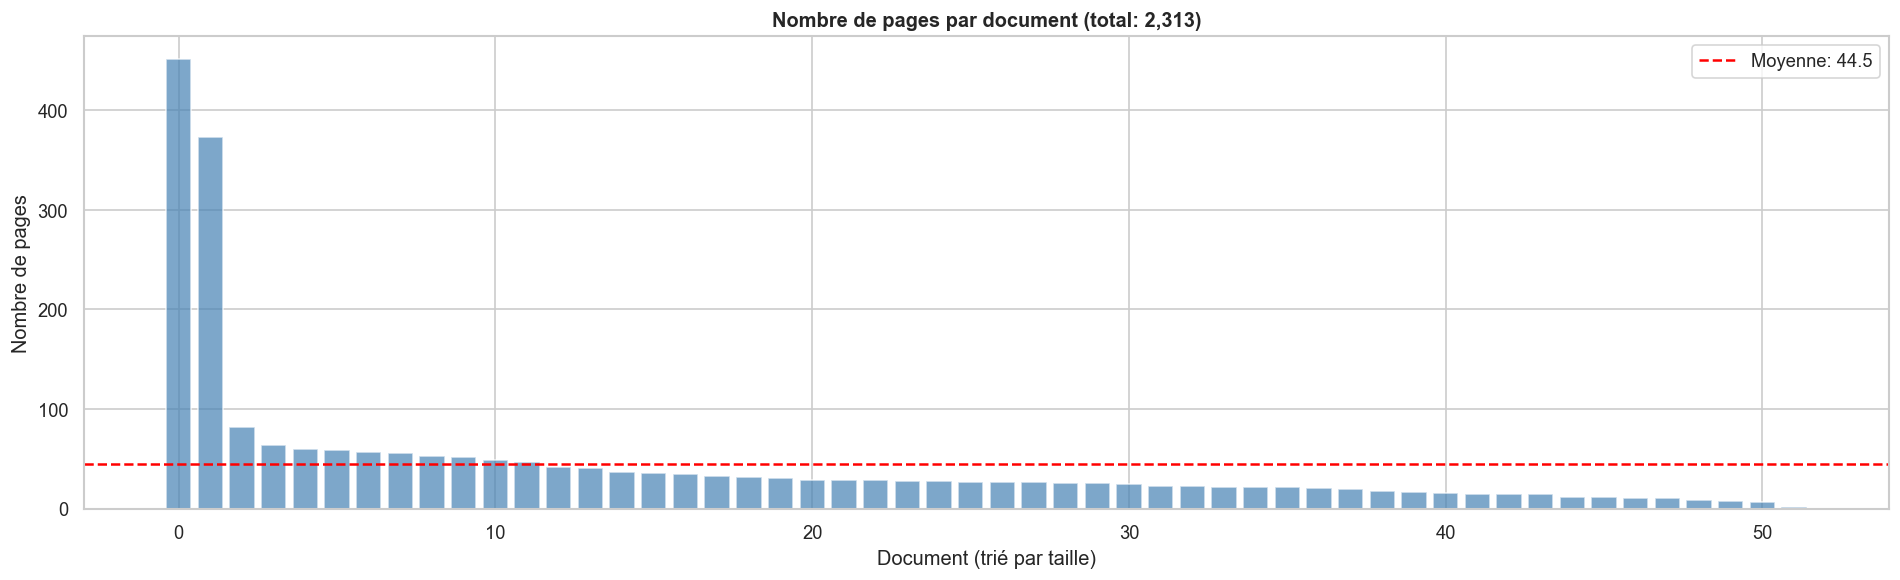

Pages par doc — min: 2, max: 452, mean: 44.5


In [5]:
fig, axes = plt.subplots(1, 1, figsize=(16, 5))

# Pages par document
pages_per_doc = df_corpus.groupby('doc_id').size().sort_values(ascending=False)
axes.bar(range(len(pages_per_doc)), pages_per_doc.values, color='steelblue', alpha=0.7)
axes.set_title(f'Nombre de pages par document (total: {len(df_corpus):,})', fontweight='bold')
axes.set_xlabel('Document (trié par taille)')
axes.set_ylabel('Nombre de pages')
axes.axhline(pages_per_doc.mean(), color='red', linestyle='--', label=f'Moyenne: {pages_per_doc.mean():.1f}')
axes.legend()

plt.tight_layout()
plt.show()
print(f'Pages par doc — min: {pages_per_doc.min()}, max: {pages_per_doc.max()}, mean: {pages_per_doc.mean():.1f}')

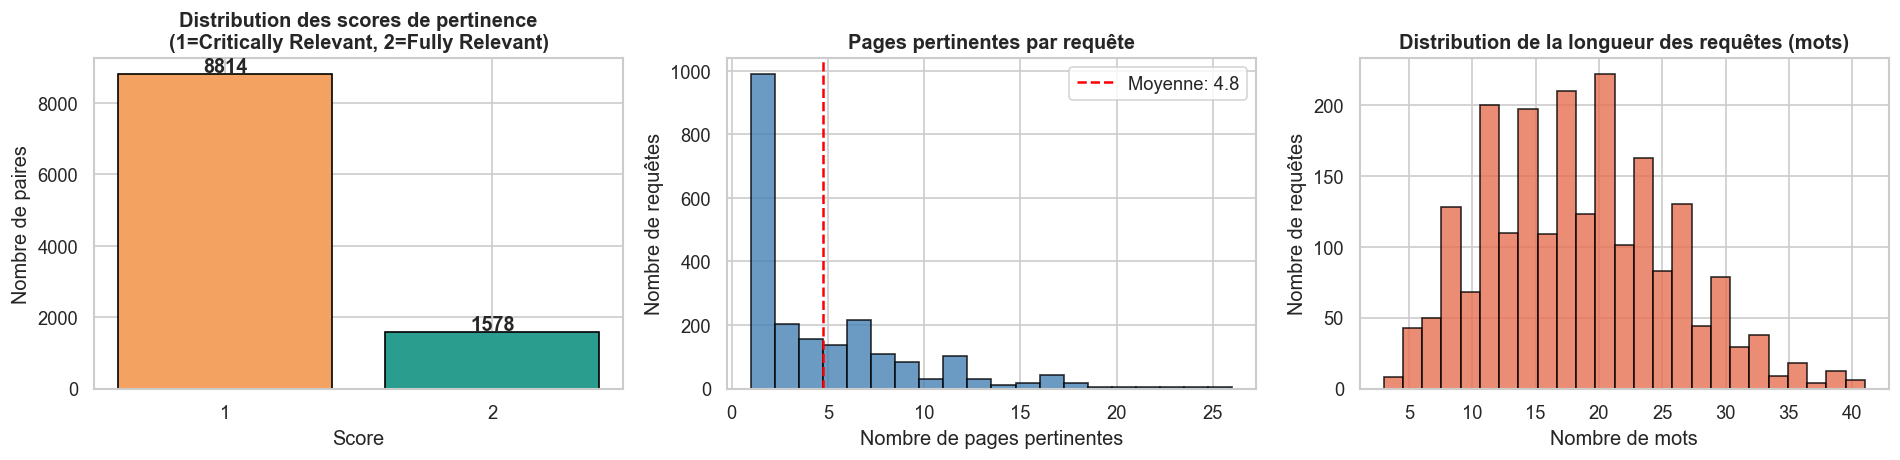

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution des scores
score_counts = df_qrels['score'].value_counts().sort_index()
axes[0].bar(score_counts.index.astype(str), score_counts.values,
            color=['#f4a261', '#2a9d8f'], edgecolor='black')
axes[0].set_title('Distribution des scores de pertinence\n(1=Critically Relevant, 2=Fully Relevant)', fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Nombre de paires')
for i, (k, v) in enumerate(score_counts.items()):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Nombre de pages pertinentes par requête
pages_per_query = df_qrels.groupby('query_id').size()
axes[1].hist(pages_per_query, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_title('Pages pertinentes par requête', fontweight='bold')
axes[1].set_xlabel('Nombre de pages pertinentes')
axes[1].set_ylabel('Nombre de requêtes')
axes[1].axvline(pages_per_query.mean(), color='red', linestyle='--',
                label=f'Moyenne: {pages_per_query.mean():.1f}')
axes[1].legend()

# Longueur des requêtes
df_queries['query_len'] = df_queries['query'].str.split().str.len()
axes[2].hist(df_queries['query_len'], bins=25, color='#e76f51', edgecolor='black', alpha=0.8)
axes[2].set_title('Distribution de la longueur des requêtes (mots)', fontweight='bold')
axes[2].set_xlabel('Nombre de mots')
axes[2].set_ylabel('Nombre de requêtes')

plt.tight_layout()
plt.show()

In [7]:
df_corpus['markdown_len'] = df_corpus['markdown'].fillna('').str.len()

qrels_with_corpus = df_qrels.merge(
    df_corpus[['corpus_id', 'markdown_len', 'doc_id', 'page_number_in_doc']],
    on='corpus_id', how='left'
)

# Filtrer score=2 (Fully Relevant) et trier par OCR croissant
poor_ocr = qrels_with_corpus[qrels_with_corpus['score'] == 2].sort_values('markdown_len')
poor_ocr_queries = poor_ocr.merge(df_queries, on='query_id', how='left')

# Diversification : prendre le pire exemple PAR doc_id, puis sélectionner 5 docs distincts
poor_ocr_per_doc = (
    poor_ocr_queries
    .sort_values('markdown_len')
    .drop_duplicates(subset='doc_id', keep='first')   # 1 requête par document
    .drop_duplicates(subset='query_id', keep='first') # sécurité
    .head(5)
)

print('=' * 80)
print('5 REQUÊTES ANTICIPANT UN ÉCHEC DU RAG TEXTUEL (documents distincts)')
print('Critère : page pertinente avec contenu OCR minimal, 1 doc différent par cas')
print('=' * 80)

for rank, (_, row) in enumerate(poor_ocr_per_doc.iterrows(), start=1):
    print(f'\n[{rank}] Query ID : {row["query_id"]}')
    print(f'    Requête  : {row["query"]}')
    print(f'    Document : {row["doc_id"]} — p.{row["page_number_in_doc"]}')
    print(f'    OCR len  : {row["markdown_len"]} chars → VISUAL-HEAVY')
    # Diagnostic automatique du type de problème visuel attendu
    q = row["query"].lower()
    if any(w in q for w in ['percentage', '%', 'rate', 'ratio', 'mean', 'median', 'number of', 'how many']):
        reason = 'Valeur numérique dans un tableau statistique'
    elif any(w in q for w in ['figure', 'graph', 'chart', 'curve', 'trend', 'plot']):
        reason = 'Donnée encodée dans une figure ou un graphique'
    elif any(w in q for w in ['mechanism', 'pathway', 'structure', 'diagram', 'process']):
        reason = 'Information dans un schéma ou diagramme de mécanisme'
    else:
        reason = 'Structure visuelle de la page non capturée par OCR seul'
    print(f'    Raison   : {reason}')

hard_cases = poor_ocr_per_doc  # réassigner pour la cellule de visualisation suivante

5 REQUÊTES ANTICIPANT UN ÉCHEC DU RAG TEXTUEL (documents distincts)
Critère : page pertinente avec contenu OCR minimal, 1 doc différent par cas

[1] Query ID : 1603
    Requête  : Kombiniert EBP klinische Fachkompetenz, Forschungsergebnisse und Patientenpräferenzen, um fundierte, individuelle Versorgungsentscheidungen zu unterstützen?
    Document : The_Public_Health_Role_of_Drug_Regulation_in_the_US — p.20
    OCR len  : 118 chars → VISUAL-HEAVY
    Raison   : Structure visuelle de la page non capturée par OCR seul

[2] Query ID : 887
    Requête  : ¿Cuáles son los tres tipos de estimaciones de contracción de la FDA según la cantidad de préstamo?
    Document : UseofBayesianHierarchicalModelsinthePresentationofSubgroupAnalyses — p.32
    OCR len  : 121 chars → VISUAL-HEAVY
    Raison   : Structure visuelle de la page non capturée par OCR seul

[3] Query ID : 197
    Requête  : Explain how did the FDA's refuse to receive percentage in FY 16 compare to FY 15.
    Document : SallyCKeynot

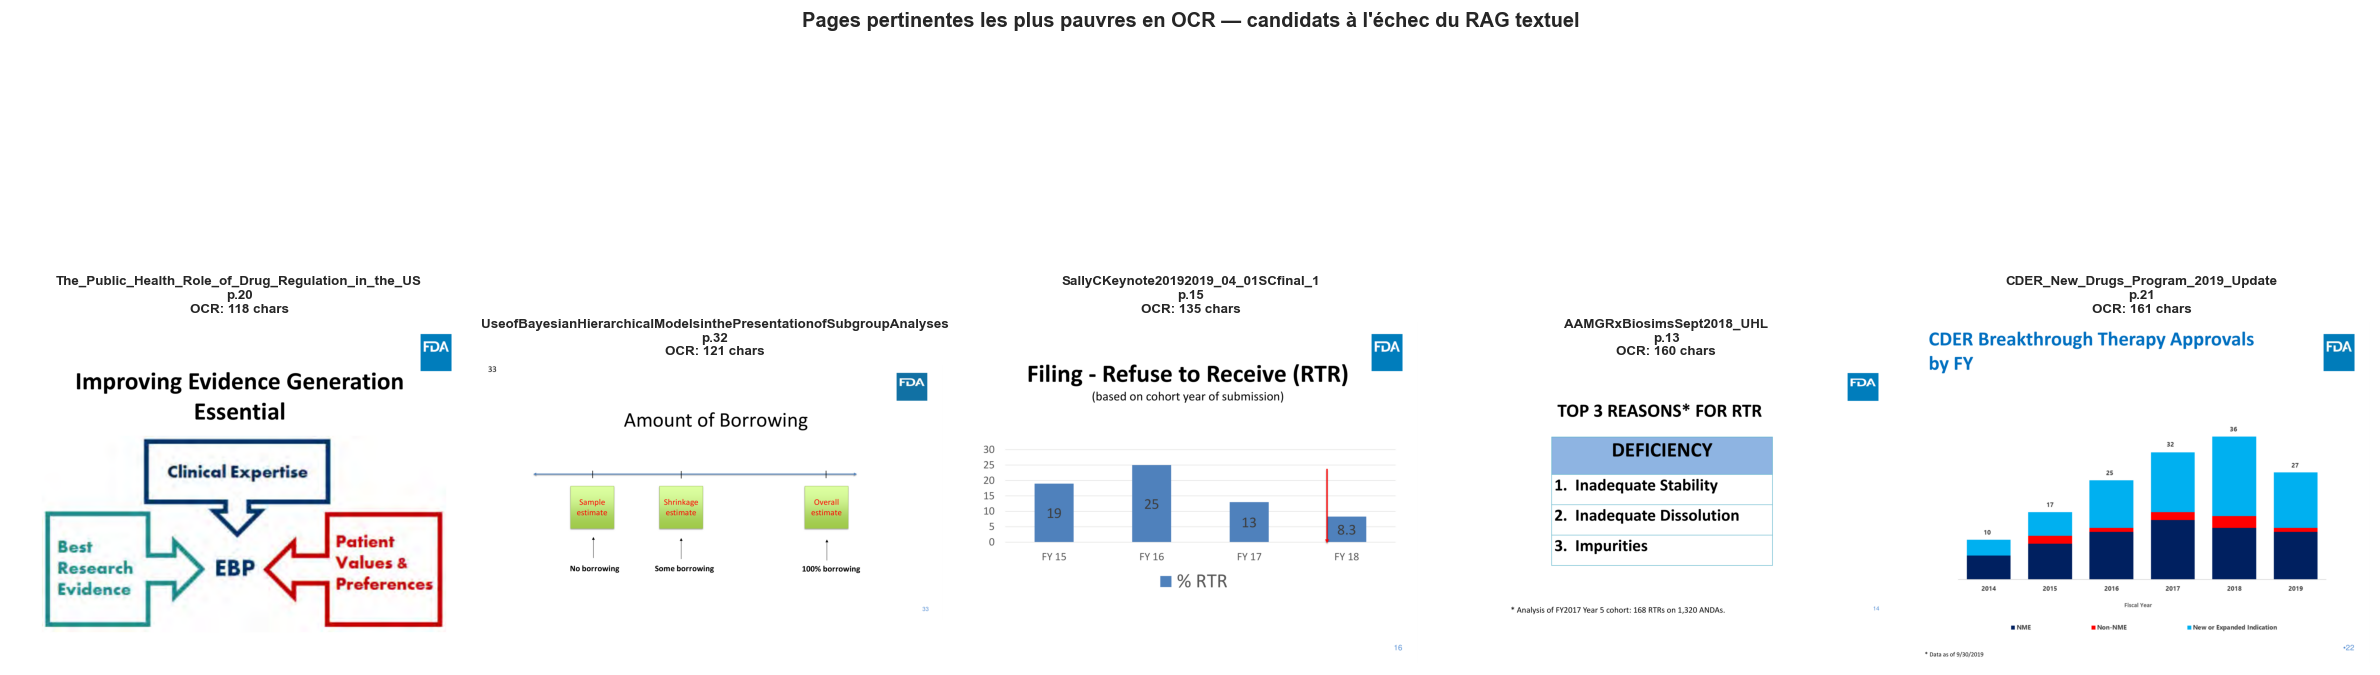

In [8]:
from PIL import Image as PILImage
import numpy as np

corpus_dict = {row['corpus_id']: row for _, row in df_corpus.iterrows()}

fig, axes = plt.subplots(1, min(5, len(hard_cases)), figsize=(20, 8))
if len(hard_cases) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, hard_cases.iterrows()):
    corpus_id = row['corpus_id']
    if corpus_id in corpus_dict:
        page_data = corpus_dict[corpus_id]
        
        # Fix: handle PIL Image wrapped in various formats
        img = page_data['image']
        if isinstance(img, dict):
            # HuggingFace stores images as {'bytes': b'...', 'path': None}
            import io
            img = PILImage.open(io.BytesIO(img['bytes'])).convert('RGB')
        elif not isinstance(img, PILImage.Image):
            img = PILImage.fromarray(np.array(img)).convert('RGB')
        else:
            img = img.convert('RGB')
        
        ax.imshow(np.array(img))
        ax.set_title(
            f'{page_data["doc_id"]}\np.{page_data["page_number_in_doc"]}\nOCR: {page_data["markdown_len"]} chars',
            fontsize=8, fontweight='bold'
        )
        ax.axis('off')

plt.suptitle("Pages pertinentes les plus pauvres en OCR — candidats à l'échec du RAG textuel",
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# BioBERT fine-tuné sur STS biomédicale — adapté au vocabulaire pharmaceutique/clinique
# Dimension : 768 | CPU-friendly
MODEL_NAME_A = 'pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb'
print(f'Chargement modèle : {MODEL_NAME_A}')
device = "cuda" if torch.cuda.is_available() else "cpu"
model_a = SentenceTransformer(MODEL_NAME_A, device='cpu')
print('Modèle chargé.')

Chargement modèle : pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modèle chargé.


In [10]:
# Préparation du corpus textuel
# On préfixe avec 'passage: ' selon les recommandations multilingual-e5
corpus_texts = [
    f"passage: {row['markdown']}" if row['markdown'] else 'passage: [empty page]'
    for _, row in df_corpus.iterrows()
]
corpus_ids = df_corpus['corpus_id'].tolist()

print(f'Encodage de {len(corpus_texts):,} pages...')
BATCH_SIZE = 64
corpus_embeddings_a = model_a.encode(
    corpus_texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True
)
print(f'Embeddings corpus shape: {corpus_embeddings_a.shape}')

Encodage de 2,313 pages...


Batches:   0%|          | 0/37 [00:00<?, ?it/s]

Embeddings corpus shape: (2313, 768)


In [11]:
# Encodage des requêtes
query_texts = [
    f"query: {row['query']}" for _, row in df_queries.iterrows()
]
query_ids = df_queries['query_id'].tolist()

print(f'Encodage de {len(query_texts):,} requêtes...')
query_embeddings_a = model_a.encode(
    query_texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True
)
print(f'Embeddings requêtes shape: {query_embeddings_a.shape}')

Encodage de 2,184 requêtes...


Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Embeddings requêtes shape: (2184, 768)


In [12]:
def compute_retrieval_results(query_embeddings, corpus_embeddings, query_ids, corpus_ids, k=10):
    """
    Calcule les top-k résultats de retrieval pour chaque requête.
    Retourne un dict {query_id: [(corpus_id, score), ...]}
    """
    results = {}
    # Calcul de la similarité cosinus par batch pour économiser la mémoire
    batch_size = 256
    for i in tqdm(range(0, len(query_ids), batch_size), desc='Computing similarities'):
        batch_q_emb = query_embeddings[i:i+batch_size]
        batch_q_ids = query_ids[i:i+batch_size]
        sims = cosine_similarity(batch_q_emb, corpus_embeddings)  # (batch, corpus)
        top_k_indices = np.argsort(-sims, axis=1)[:, :k]
        for j, qid in enumerate(batch_q_ids):
            results[qid] = [
                (corpus_ids[idx], float(sims[j, idx]))
                for idx in top_k_indices[j]
            ]
    return results

print('Calcul des résultats de retrieval (Approche A)...')
results_a = compute_retrieval_results(
    query_embeddings_a, corpus_embeddings_a, query_ids, corpus_ids, k=10
)
print(f'Résultats calculés pour {len(results_a):,} requêtes.')

Calcul des résultats de retrieval (Approche A)...


Computing similarities:   0%|          | 0/9 [00:00<?, ?it/s]

Résultats calculés pour 2,184 requêtes.


In [13]:
def compute_ndcg_at_k(results, df_qrels, k=5):
    """
    Calcule le nDCG@k pour chaque requête.
    results: dict {query_id: [(corpus_id, score), ...]}
    df_qrels: DataFrame avec colonnes query_id, corpus_id, score
    """
    # Construire le dict de ground truth {query_id: {corpus_id: score}}
    gt = defaultdict(dict)
    for _, row in df_qrels.iterrows():
        gt[row['query_id']][row['corpus_id']] = row['score']

    ndcg_scores = {}
    for qid, ranked_list in results.items():
        if qid not in gt:
            continue
        relevant = gt[qid]
        # DCG@k
        dcg = 0.0
        for rank, (cid, _) in enumerate(ranked_list[:k], start=1):
            rel = relevant.get(cid, 0)
            dcg += (2**rel - 1) / np.log2(rank + 1)
        # IDCG@k (tri par score décroissant)
        ideal_rels = sorted(relevant.values(), reverse=True)[:k]
        idcg = sum(
            (2**rel - 1) / np.log2(rank + 1)
            for rank, rel in enumerate(ideal_rels, start=1)
        )
        ndcg_scores[qid] = dcg / idcg if idcg > 0 else 0.0
    return ndcg_scores

ndcg_a = compute_ndcg_at_k(results_a, df_qrels, k=5)
mean_ndcg_a = np.mean(list(ndcg_a.values()))
print(f'\n{"="*50}')
print(f'  Approche A — nDCG@5 : {mean_ndcg_a:.4f}')
print(f'  Médiane             : {np.median(list(ndcg_a.values())):.4f}')
print(f'  % requêtes à 0.0   : {sum(1 for v in ndcg_a.values() if v == 0) / len(ndcg_a) * 100:.1f}%')
print(f'  % requêtes à 1.0   : {sum(1 for v in ndcg_a.values() if v == 1) / len(ndcg_a) * 100:.1f}%')
print(f'  N requêtes évaluées: {len(ndcg_a):,}')
print('='*50)


  Approche A — nDCG@5 : 0.1029
  Médiane             : 0.0000
  % requêtes à 0.0   : 78.5%
  % requêtes à 1.0   : 2.7%
  N requêtes évaluées: 2,184


In [14]:
# --- Analyse qualitative des 10 pires résultats ---
worst_queries_a = sorted(ndcg_a.items(), key=lambda x: x[1])[:10]

print('TOP 10 PIRES REQUÊTES — Approche A (textuelle)')
print('='*80)

gt_dict = defaultdict(dict)
for _, row in df_qrels.iterrows():
    gt_dict[row['query_id']][row['corpus_id']] = row['score']

query_text_dict  = dict(zip(df_queries['query_id'], df_queries['query']))
corpus_meta_dict = dict(zip(df_corpus['corpus_id'],
                            zip(df_corpus['doc_id'],
                                df_corpus['page_number_in_doc'],
                                df_corpus['markdown_len'])))

worst_analysis = []
for qid, score in worst_queries_a:
    query_text = query_text_dict.get(qid, 'N/A')
    relevant_pages = gt_dict.get(qid, {})
    retrieved_top1 = results_a[qid][0][0] if results_a[qid] else None

    # Info sur les pages pertinentes attendues
    rel_info = []
    for cid, rel_score in relevant_pages.items():
        meta = corpus_meta_dict.get(cid, ('?', '?', 0))
        rel_info.append(f'{meta[0]} p.{meta[1]} (score={rel_score}, ocr_len={meta[2]})')

    print(f'\nnDCG@5={score:.3f} | QID: {qid}')
    print(f'  Requête   : {query_text}')
    print(f'  Attendu   : {" | ".join(rel_info)}')
    if retrieved_top1:
        meta_r = corpus_meta_dict.get(retrieved_top1, ('?', '?', 0))
        print(f'  Récupéré  : {meta_r[0]} p.{meta_r[1]} (ocr_len={meta_r[2]})')

    worst_analysis.append({
        'query_id': qid, 'ndcg_a': score,
        'query': query_text,
        'expected_doc': rel_info[0] if rel_info else 'N/A'
    })

df_worst_a = pd.DataFrame(worst_analysis)
print('\n\nRésumé tableau des 10 pires requêtes A :')
display(df_worst_a[['query', 'ndcg_a', 'expected_doc']])

TOP 10 PIRES REQUÊTES — Approche A (textuelle)

nDCG@5=0.000 | QID: 1
  Requête   : FDA meeting response times before and during pandemic surge
  Attendu   : NASEUAworkshop21_PCavazzoni_forposting p.4 (score=2, ocr_len=514)
  Récupéré  : State_of_CDER_FDLI2021_PCavazzoni_20210515 p.1 (ocr_len=32)

nDCG@5=0.000 | QID: 6
  Requête   : Identify the FDA programs focused on enhancing access to generic medications and explain how these initiatives connect with actions taken to address the opioid epidemic.
  Attendu   : AAMGRxBiosimsSept2018_UHL p.26 (score=1, ocr_len=766) | AAMGRxBiosimsSept2018_UHL p.37 (score=1, ocr_len=482) | AAMGRxBiosimsSept2018_UHL p.40 (score=1, ocr_len=533) | AAMGRxBiosimsSept2018_UHL p.46 (score=1, ocr_len=438) | AAMGRxBiosimsSept2018_UHL p.6 (score=1, ocr_len=495) | State_of_CDER_FDLI2021_PCavazzoni_20210515 p.19 (score=1, ocr_len=568)
  Récupéré  : Presentation_FDA_Perspective_on_Abuse_Deterrent_Opioid_Development p.19 (ocr_len=421)

nDCG@5=0.000 | QID: 7
  Requêt

,query,ndcg_a,expected_doc
0,FDA meeting response times before and during p...,0.0,NASEUAworkshop21_PCavazzoni_forposting p.4 (sc...
1,Identify the FDA programs focused on enhancing...,0.0,"AAMGRxBiosimsSept2018_UHL p.26 (score=1, ocr_l..."
2,Contrast Anne-Emanuelle Birn's critique of str...,0.0,"drug_resistance_book p.318 (score=2, ocr_len=3..."
3,What distinguishes the approaches of proactive...,0.0,DDI_Medication_Errors_CE_March_2020_DMEPA_and_...
4,Explain how the tiered structure of evidence i...,0.0,Biosimilar_Regulatory_Policy_Understanding_the...
5,How do past performance data influence the dev...,0.0,FDA_Office_of_Generic_Drugs_OGD_Keynote_Addres...
6,Analyze the role of international regulatory c...,0.0,Future_of_Drug_Development_with_Janet_Woodcock...
7,patterns in SEND usage growth for investigatio...,0.0,"CDER_SEND_Webinar_June_2020 p.35 (score=1, ocr..."
8,"According to FDA guidelines, what is the requi...",0.0,DDI_Medication_Errors_CE_March_2020_DMEPA_and_...
9,How do the concentration-related risks of remd...,0.0,DDI_Medication_Errors_CE_March_2020_DMEPA_and_...


In [40]:
# ── Fonctions d'encodage CUDA ─────────────────────────────────────────────────

def encode_images_colpali(images, model, processor, batch_size=1):
    all_embeddings = []
    for i in tqdm(range(0, len(images), batch_size), desc='Encoding images'):
        batch_imgs = images[i:i+batch_size]
        with torch.no_grad():
            batch_doc = processor.process_images(batch_imgs).to(DEVICE)  # CUDA
            embs = model(**batch_doc)
        all_embeddings.extend(list(embs.to(torch.float32).cpu().unbind(0)))  # stocker sur RAM
        del embs, batch_doc
        torch.cuda.empty_cache()
    return all_embeddings

def encode_queries_colpali(queries, model, processor, batch_size=1):
    all_embeddings = []
    for i in tqdm(range(0, len(queries), batch_size), desc='Encoding queries'):
        batch_q = queries[i:i+batch_size]
        with torch.no_grad():
            batch_q_proc = processor.process_queries(batch_q).to(DEVICE)  # CUDA
            embs = model(**batch_q_proc)
        all_embeddings.extend(list(embs.to(torch.float32).cpu().unbind(0)))
        del embs, batch_q_proc
        torch.cuda.empty_cache()
    return all_embeddings

def colpali_score(query_emb, doc_emb):
    # MaxSim sur CPU — embeddings déjà rapatriés
    scores = torch.einsum('qd,pd->qp', query_emb, doc_emb)
    return scores.max(dim=1).values.sum().item()

from PIL import Image as PILImage
import io
import numpy as np

def safe_to_pil(img):
    """Convertit n'importe quel format d'image HuggingFace en PIL RGB."""
    if isinstance(img, dict):
        # Format HuggingFace brut : {'bytes': b'...', 'path': None}
        return PILImage.open(io.BytesIO(img['bytes'])).convert('RGB')
    elif isinstance(img, PILImage.Image):
        return img.convert('RGB')
    else:
        # numpy array ou autre
        return PILImage.fromarray(np.array(img)).convert('RGB')


In [ ]:
MAX_CORPUS_PAGES = 2310  # corpus complet
MAX_QUERIES      = 2180  # toutes les requêtes

df_corpus_sample = df_corpus.copy()
valid_corpus_ids  = set(df_corpus_sample['corpus_id'])
valid_qrels       = df_qrels[df_qrels['corpus_id'].isin(valid_corpus_ids)]
valid_query_ids   = set(valid_qrels['query_id'].unique())
df_queries_sample = df_queries[df_queries['query_id'].isin(valid_query_ids)]

print(f'Corpus  : {len(df_corpus_sample):,} pages')
print(f'Queries : {len(df_queries_sample):,} requêtes')
print(f'VRAM disponible : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1e9:.2f} Go')

# ── Encodage images ───────────────────────────────────────────────────────────
print('\nEncodage images (ColSmol-500M, CUDA)...')
corpus_images = [safe_to_pil(row['image']) for _, row in tqdm(
                  df_corpus_sample.iterrows(), total=len(df_corpus_sample), desc='PIL conversion')]
corpus_ids_b  = df_corpus_sample['corpus_id'].tolist()
corpus_embs_b = encode_images_colpali(corpus_images, model_b, processor_b, batch_size=1)
print(f'Images encodées : {len(corpus_embs_b)}')
print(f'VRAM après encodage : {torch.cuda.memory_allocated()/1e9:.2f} Go')

# ── Encodage requêtes ─────────────────────────────────────────────────────────
print('\nEncodage requêtes (ColSmol-500M, CUDA)...')
query_texts_b = df_queries_sample['query'].tolist()
query_ids_b   = df_queries_sample['query_id'].tolist()
query_embs_b  = encode_queries_colpali(query_texts_b, model_b, processor_b, batch_size=1)
print(f'Requêtes encodées : {len(query_embs_b)}')

Corpus  : 2,313 pages
Queries : 2,184 requêtes
VRAM disponible : 8.11 Go

Encodage images (ColSmol-500M, CUDA)...


PIL conversion:   0%|          | 0/2313 [00:00<?, ?it/s]

In [ ]:
# Calcul des scores MaxSim pour chaque (query, page)
print('Calcul des scores MaxSim ColPali...')
results_b = {}

for i, (qid, q_emb) in enumerate(tqdm(zip(query_ids_b, query_embs_b), total=len(query_ids_b))):
    scores = [
        (cid, colpali_score(q_emb, d_emb))
        for cid, d_emb in zip(corpus_ids_b, corpus_embs_b)
    ]
    results_b[qid] = sorted(scores, key=lambda x: -x[1])[:10]

# Évaluation nDCG@5
df_qrels_sample = df_qrels[
    df_qrels['query_id'].isin(query_ids_b) &
    df_qrels['corpus_id'].isin(corpus_ids_b)
]

ndcg_b = compute_ndcg_at_k(results_b, df_qrels_sample, k=5)
mean_ndcg_b = np.mean(list(ndcg_b.values())) if ndcg_b else 0.0

print(f'\n{"="*50}')
print(f'  Approche B — nDCG@5 : {mean_ndcg_b:.4f}')
print(f'  N requêtes évaluées : {len(ndcg_b):,}')
print('='*50)

In [ ]:
# --- Visualisation des bounding boxes sur quelques cas ---
# Pour les top requêtes bien résolues par B, afficher la page + bounding box

def draw_bounding_boxes(image, bboxes, color='red', linewidth=3):
    """Dessine les bounding boxes de vérité terrain sur une image PIL."""
    fig, ax = plt.subplots(1, 1, figsize=(8, 10))
    ax.imshow(image)
    if bboxes:
        img_w, img_h = image.size
        for bbox in bboxes:
            # bboxes sont normalisées [0,1] dans ViDoRe
            x1 = bbox.get('x1', bbox[0] if isinstance(bbox, list) else 0) * img_w
            y1 = bbox.get('y1', bbox[1] if isinstance(bbox, list) else 0) * img_h
            x2 = bbox.get('x2', bbox[2] if isinstance(bbox, list) else img_w) * img_w
            y2 = bbox.get('y2', bbox[3] if isinstance(bbox, list) else img_h) * img_h
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=linewidth, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
    ax.axis('off')
    return fig

# Prendre 3 exemples où B a bien performé
best_b = sorted(ndcg_b.items(), key=lambda x: -x[1])[:3]
corpus_img_dict = dict(zip(df_corpus_sample['corpus_id'], df_corpus_sample['image']))
qrels_bbox = df_qrels_sample.copy()

fig, axes_grid = plt.subplots(1, 3, figsize=(21, 10))
for ax, (qid, score) in zip(axes_grid, best_b):
    top_result = results_b[qid][0][0]
    img = corpus_img_dict.get(top_result)
    if img is None:
        continue
    # Récupérer les bounding boxes depuis qrels
    bbox_rows = qrels_bbox[
        (qrels_bbox['query_id'] == qid) & (qrels_bbox['corpus_id'] == top_result)
    ]
    bboxes = []
    if not bbox_rows.empty and 'bounding_boxes' in bbox_rows.columns:
        raw = bbox_rows.iloc[0]['bounding_boxes']
        if raw is not None:
            bboxes = raw if isinstance(raw, list) else [raw]

    ax.imshow(img)
    img_w, img_h = img.size
    for bbox in bboxes:
        try:
            if isinstance(bbox, dict):
                x1, y1, x2, y2 = bbox['x1']*img_w, bbox['y1']*img_h, bbox['x2']*img_w, bbox['y2']*img_h
            else:
                x1, y1, x2, y2 = [v * (img_w if i%2==0 else img_h) for i, v in enumerate(bbox)]
            rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                      linewidth=3, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
        except Exception:
            pass

    query_text = query_text_dict.get(qid, '')[:60] + '...'
    ax.set_title(f'nDCG@5={score:.3f}\n{query_text}', fontsize=8, fontweight='bold')
    ax.axis('off')

plt.suptitle('Approche B (ColPali) — Pages récupérées avec bounding boxes vérité terrain',
             fontweight='bold')
plt.tight_layout()
plt.show()